In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

argentina = pd.read_csv("Argentina.csv")
brazil = pd.read_csv("Brazil.csv")

argentina["country"] = "Argentina"
brazil["country"] = "Brazil"

df = pd.concat([argentina, brazil], ignore_index=True)

print("Combined shape:", df.shape)
print(df.head())
print(df.columns.tolist())


Combined shape: (100, 23)
                                  index  farm_identifier  field_shared_name  \
0  875ad00e-dea6-4c80-ac45-d79dd2cc2fb9               39                557   
1  4084ba43-e315-4477-9409-df8816c979f3               39                557   
2  2d0fd1b9-6f7e-4a22-ab64-eff3f345f427               39                557   
3  b86f270d-3be7-46ed-b85b-8385fbdbba3e               39                557   
4  96583946-ca16-4466-be2b-0d7244e8530e               39                557   

   crop  year  target  row  col        date  time_step  ...     B04     B05  \
0  corn  2017    5.76    0   62  2016-09-19          8  ...  1224.0  1427.0   
1  corn  2017    7.36    1   61  2016-09-19          8  ...  1230.0  1436.0   
2  corn  2017   11.62    1   62  2016-09-19          8  ...  1200.0  1405.0   
3  corn  2017   12.18    1   63  2016-09-19          8  ...  1162.0  1397.0   
4  corn  2017   12.03    1   64  2016-09-19          8  ...  1202.0  1410.0   

      B06     B07     B0

In [ ]:

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nCrop distribution:")
print(df["crop"].value_counts())

print("\nCountry distribution:")
print(df["country"].value_counts())

print("\nData types:")
print(df.dtypes)

print("\nDates by country and year:")
print(
    df.groupby(["country", "year"])["date"]
    .agg(["min", "max", "nunique"])
)


Dataset shape: (100, 23)

Missing values:
index                0
farm_identifier      0
field_shared_name    0
crop                 0
year                 0
target               0
row                  0
col                  0
date                 0
time_step            0
B01                  0
B02                  0
B03                  0
B04                  0
B05                  0
B06                  0
B07                  0
B08                  0
B09                  0
B11                  0
B12                  0
B8A                  0
country              0
dtype: int64

Duplicate rows: 0

Crop distribution:
crop
corn       34
soybean    34
wheat      32
Name: count, dtype: int64

Country distribution:
country
Argentina    50
Brazil       50
Name: count, dtype: int64

Data types:
index                 object
farm_identifier        int64
field_shared_name      int64
crop                  object
year                   int64
target               float64
row                    int64

In [ ]:

denominator = df["B08"] + df["B04"]

df["NDVI"] = np.where(
    denominator != 0,
    (df["B08"] - df["B04"]) / denominator,
    np.nan
)

print(df[["country", "crop", "date", "B04", "B08", "NDVI"]].head(10))

print("\nNDVI summary:")
print(df["NDVI"].describe())

print("\nInvalid NDVI values:")
print(((df["NDVI"] < -1) | (df["NDVI"] > 1)).sum())


     country  crop        date     B04     B08      NDVI
0  Argentina  corn  2016-09-19  1224.0  1976.0  0.235000
1  Argentina  corn  2016-09-19  1230.0  2018.0  0.242611
2  Argentina  corn  2016-09-19  1200.0  1890.0  0.223301
3  Argentina  corn  2016-09-19  1162.0  1800.0  0.215395
4  Argentina  corn  2016-09-19  1202.0  1782.0  0.194370
5  Argentina  corn  2016-09-19  1262.0  1898.0  0.201266
6  Argentina  corn  2016-09-19  1184.0  1960.0  0.246819
7  Argentina  corn  2016-09-19  1184.0  1840.0  0.216931
8  Argentina  corn  2016-09-19  1162.0  1810.0  0.218035
9  Argentina  corn  2016-09-19  1180.0  1746.0  0.193438

NDVI summary:
count    100.000000
mean       0.356619
std        0.147637
min        0.188425
25%        0.223291
50%        0.289264
75%        0.484280
max        0.676349
Name: NDVI, dtype: float64

Invalid NDVI values:
0


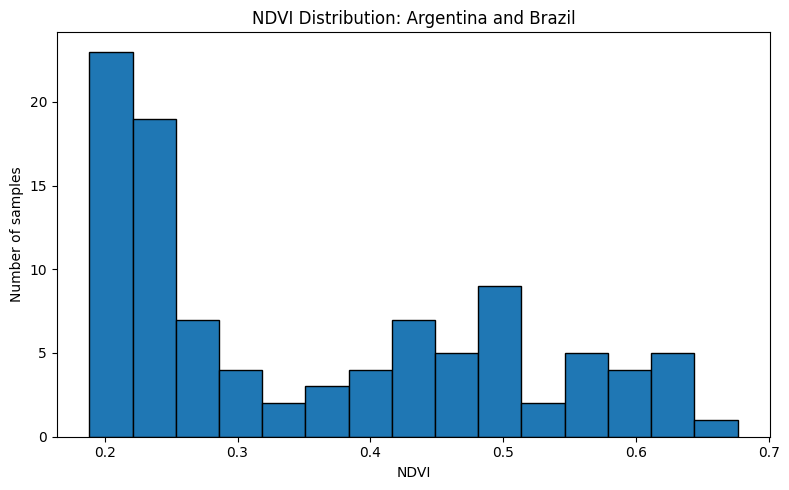

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(df["NDVI"].dropna(), bins=15, edgecolor="black")
plt.xlabel("NDVI")
plt.ylabel("Number of samples")
plt.title("NDVI Distribution: Argentina and Brazil")
plt.tight_layout()
plt.show()


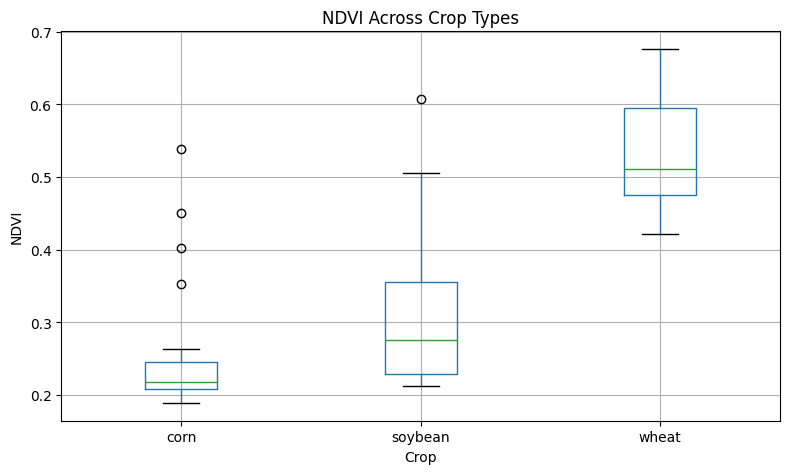

In [ ]:

df.boxplot(column="NDVI", by="crop", figsize=(8, 5))
plt.title("NDVI Across Crop Types")
plt.suptitle("")
plt.xlabel("Crop")
plt.ylabel("NDVI")
plt.tight_layout()
plt.show()


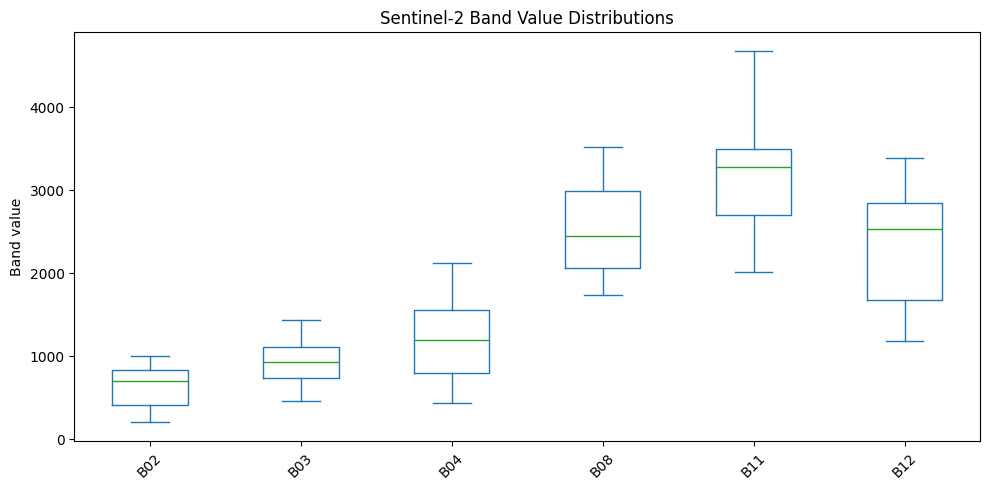

In [ ]:

bands = ["B02", "B03", "B04", "B08", "B11", "B12"]

df[bands].plot(
    kind="box",
    figsize=(10, 5)
)

plt.title("Sentinel-2 Band Value Distributions")
plt.ylabel("Band value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

df.to_csv("Margi_Week3_Optical_Features.csv", index=False)

files.download("Margi_Week3_Optical_Features.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 2: Data Inspection and Quality Checks

### Objective
In this step, I inspected the Argentina and Brazil datasets shared by Ahladita to understand the data and check whether it was ready for further processing.

### Dataset Overview
Both datasets contain 50 rows and 22 columns, giving a total of 100 records. They include information such as crop type, dates, farm and field identifiers, and Sentinel-2 spectral band values.

### Data Quality Checks
I checked both datasets for missing values and duplicate records. No missing values or duplicate rows were found, which means the data is complete in these basic checks.

The combined dataset contains 34 records for corn, 34 for soybean, and 32 for wheat. I also checked the available spectral bands, including B04 (red) and B08 (near-infrared), which are needed to calculate NDVI.

While checking the dates, I noticed that the year in some records does not match the year mentioned in the `date` column. I will need to clarify this before using the data for further time-based analysis.

### NDVI Calculation
I calculated the Normalized Difference Vegetation Index (NDVI) using the red band (B04) and the near-infrared band (B08).

NDVI = (B08 − B04) / (B08 + B04)

The calculation was completed for all 100 records. The average NDVI was approximately 0.3566, with values ranging from 0.1884 to 0.6763. All the calculated values were within the expected range of −1 to +1.

### Conclusion
Overall, the initial checks went well, and I was able to calculate NDVI for all 100 records. The data is ready for basic optical analysis and visualization. However, I still need to clarify the differences between some dates and years and verify the field identifiers. The next step is to inspect the plots and, once Priyanshi shares the Sentinel-1 data, check the VV and VH values and work towards combining the optical and SAR features.


In [1]:

import rasterio
from google.colab import files

uploaded = files.upload()

tif_path = "SAR_VV_VH_Test.tif"

with rasterio.open(tif_path) as src:
    sar = src.read()
    print("Number of bands:", src.count)
    print("Raster dimensions:", src.height, "x", src.width)
    print("CRS:", src.crs)
    print("Pixel size:", src.res)
    print("Band descriptions:", src.descriptions)
    print("No-data value:", src.nodata)


Saving SAR_VV_VH_Test.tif to SAR_VV_VH_Test.tif
Number of bands: 2
Raster dimensions: 11 x 11
CRS: EPSG:32614
Pixel size: (10.0, 10.0)
Band descriptions: ('VV', 'VH')
No-data value: None


In [4]:

import numpy as np
import rasterio

with rasterio.open("SAR_VV_VH_Test.tif") as src:
    vv = src.read(1, masked=True).astype(float).filled(np.nan)
    vh = src.read(2, masked=True).astype(float).filled(np.nan)

for name, band in [("VV", vv), ("VH", vh)]:
    valid = np.isfinite(band)

    print(f"\n{name} statistics")
    print("Valid pixels:", np.sum(valid))
    print("Missing pixels:", np.sum(~valid))

    if np.any(valid):
        print("Minimum:", np.nanmin(band))
        print("Maximum:", np.nanmax(band))
        print("Mean:", np.nanmean(band))
        print("Standard deviation:", np.nanstd(band))
    else:
        print("No valid pixels found.")



VV statistics
Valid pixels: 121
Missing pixels: 0
Minimum: -20.682638352596943
Maximum: -10.134100932080116
Mean: -13.910383913411673
Standard deviation: 2.157599146670713

VH statistics
Valid pixels: 121
Missing pixels: 0
Minimum: -27.428112981630967
Maximum: -15.48243430683953
Mean: -20.08177243822457
Standard deviation: 2.8922888607591415


In [7]:
import matplotlib.pyplot as plt


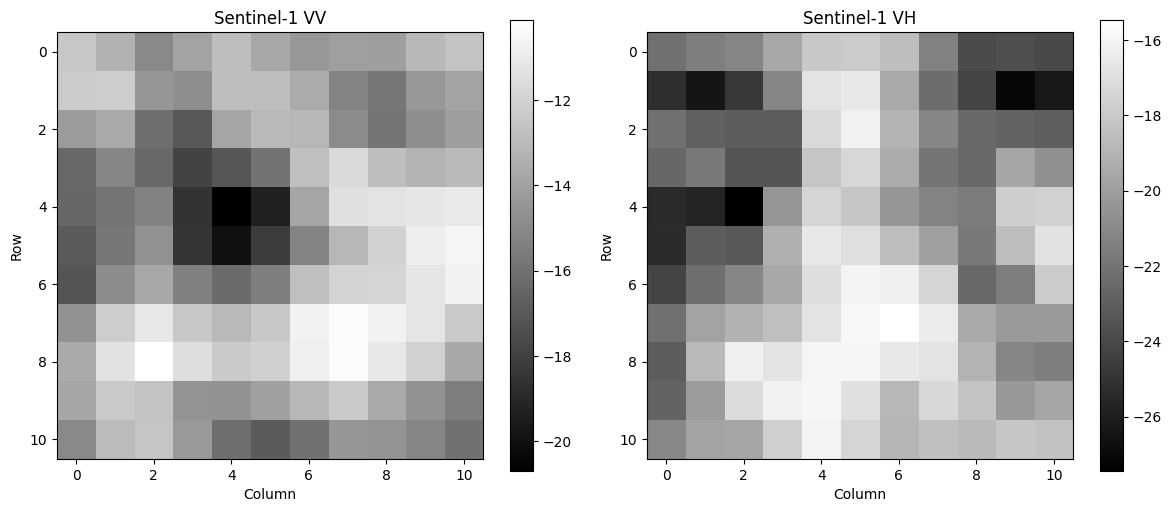

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(vv, cmap="gray")
axes[0].set_title("Sentinel-1 VV")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(vh, cmap="gray")
axes[1].set_title("Sentinel-1 VH")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


The Sentinel-1 test raster has two bands, VV and VH, with 121 valid pixels in each and no missing values. The average VV value is around -13.91, while the average VH value is around -20.08. I also plotted both bands to get a better idea of how the data is distributed.